In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import scipy.ndimage as ndimage
import glob, os, shutil, cv2, json, sys
from tqdm import tqdm
from pathlib import Path

In [2]:
BASE_PATH = '../Dataset/dataset_mix'

In [3]:
def getFiles(path, limit=None, shuffle=False):
    target = sorted([os.path.abspath(f) for f in glob.glob(os.path.join(path, '*'))])
    if shuffle:
        np.random.shuffle(target)     
    return target[:limit]

def setFolder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)


OPTIONS = json.loads(open('../../Task/info.json', 'r').read())
OPTIONS['dataset'] = BASE_PATH.split('/')[-1].strip()
OPTIONS

{'network': 'segresnet_mix',
 'dataset': 'dataset_mix',
 'img_size': None,
 'lr': 0.001,
 'loss': 'dice_focal',
 'batch_size': 2,
 'scheduler': 'plateau',
 'dropout': 0.1,
 'num_filters': 16}

In [4]:
with open('../../Task/info.json', 'w', encoding='utf-8') as file:
    json.dump(OPTIONS, file, ensure_ascii=False, indent=4) 

In [5]:
wu_images = getFiles('../dataset1/images')
wu_masks  = getFiles('../dataset1/masks')

print(len(wu_images))
wu_images[:5]

220


['/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/0.npy',
 '/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/1.npy',
 '/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/10.npy',
 '/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/100.npy',
 '/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/101.npy']

In [6]:
sy_images = getFiles('../dataset3/images')
sy_masks  = getFiles('../dataset3/masks')
print(len(sy_images))
sy_masks[:5]

110


['/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset3/masks/img_0000.npy',
 '/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset3/masks/img_0001.npy',
 '/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset3/masks/img_0002.npy',
 '/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset3/masks/img_0003.npy',
 '/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset3/masks/img_0004.npy']

In [7]:
df = pd.DataFrame()
df['img_path']  = wu_images + sy_images
df['mask_path'] = wu_masks  + sy_masks
df['shape'] = '(128, 128, 128)'
df

,img_path,mask_path,shape
0,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
1,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
2,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
3,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
4,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
...,...,...,...
325,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
326,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
327,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"
328,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...,"(128, 128, 128)"


In [8]:
info = []

for img_path, mask_path in tqdm(zip(df.img_path, df.mask_path)):
    img  = np.load(img_path)
    mask = np.load(mask_path)
    data = dict()

    data['id'] = Path(img_path).name
    data['img_min']  = np.min(img)
    data['img_max']  = np.max(img)
    data['img_mean'] = np.mean(img)
    data['img_std']  = np.std(img)

    data['msk_min'] = np.min(mask)
    data['msk_max'] = np.max(mask)

    data['shape'] = img.shape
    data['img_path']  = img_path
    data['mask_path'] = mask_path
    info.append(data)


df = pd.DataFrame(info)
print(df.img_path.iloc[2])
df

330it [00:03, 88.51it/s] 

/media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/10.npy


,id,img_min,img_max,img_mean,img_std,msk_min,msk_max,shape,img_path,mask_path
0,0.npy,0.0,1.0,0.497236,0.211666,0.0,1.0,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
1,1.npy,0.0,1.0,0.496481,0.184599,0.0,1.0,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
2,10.npy,0.0,1.0,0.496158,0.185499,0.0,1.0,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
3,100.npy,0.0,1.0,0.496550,0.203066,0.0,1.0,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
4,101.npy,0.0,1.0,0.497008,0.210493,0.0,1.0,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
...,...,...,...,...,...,...,...,...,...,...
325,img_0105.npy,0.0,1.0,0.501312,0.186325,0.0,1.0,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
326,img_0106.npy,0.0,1.0,0.499058,0.194485,0.0,1.0,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
327,img_0107.npy,0.0,1.0,0.500245,0.195928,0.0,1.0,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...
328,img_0108.npy,0.0,1.0,0.498880,0.195373,0.0,1.0,"(128, 128, 128)",/media/grva-mintcave/BACKUP/marlim_faults/Klau...,/media/grva-mintcave/BACKUP/marlim_faults/Klau...


wu

 /media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/0.npy


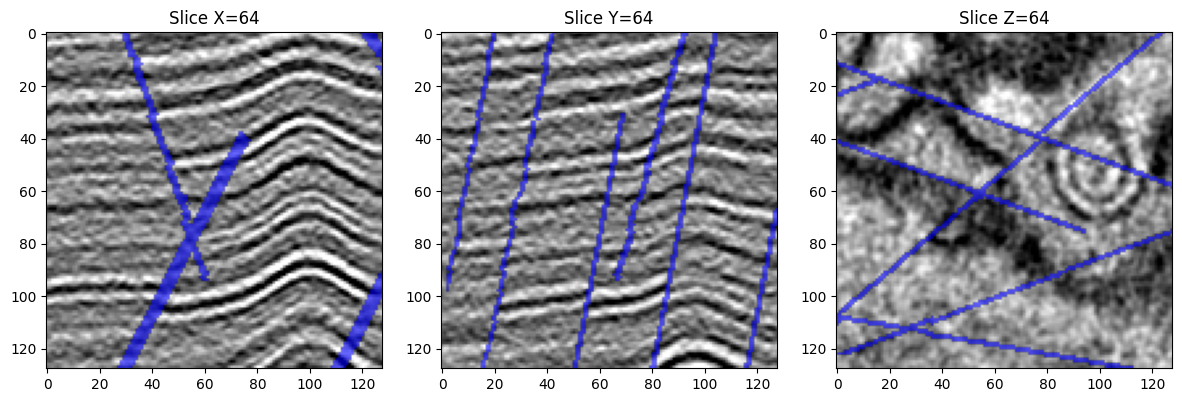

wu

 /media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/1.npy


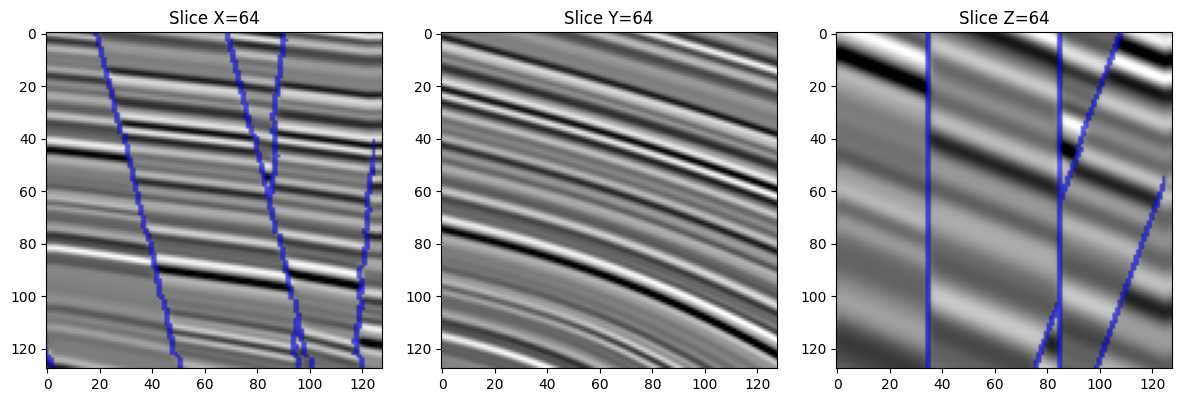

wu

 /media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/10.npy


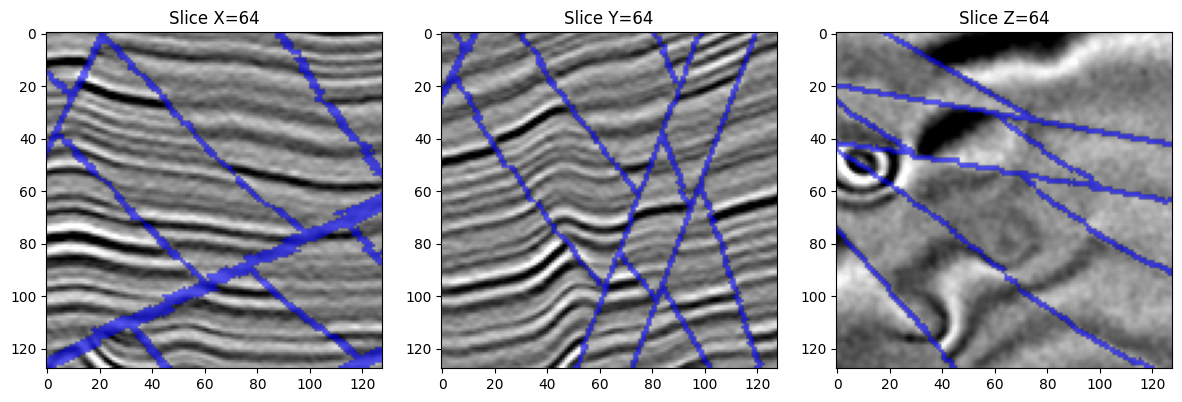

wu

 /media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/100.npy


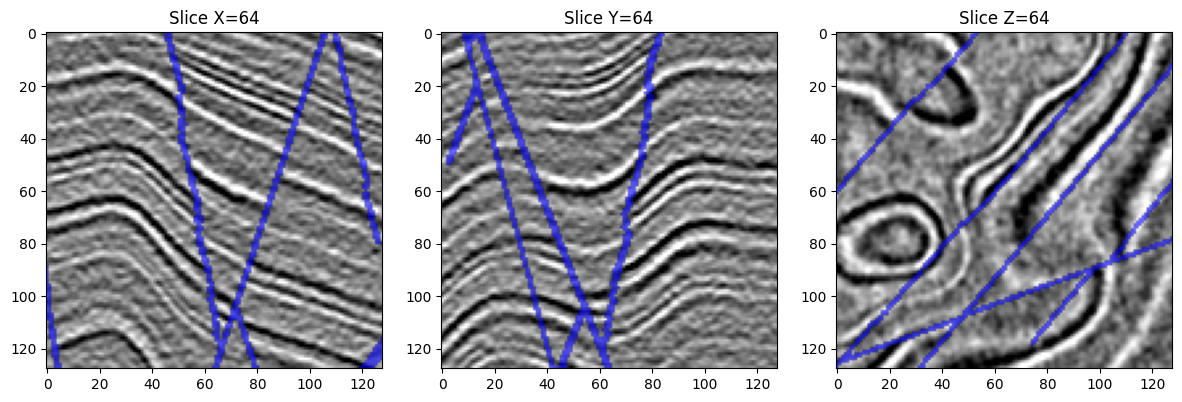

wu

 /media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/101.npy


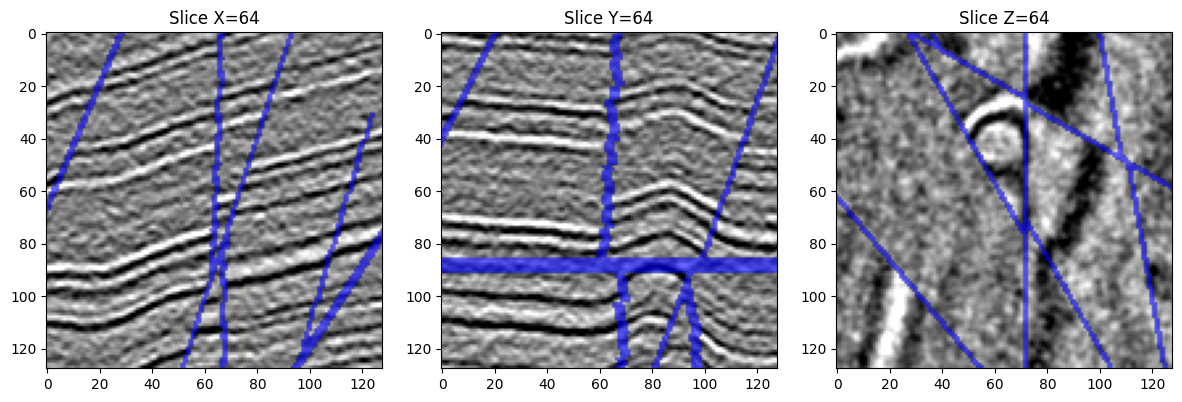

wu

 /media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/102.npy


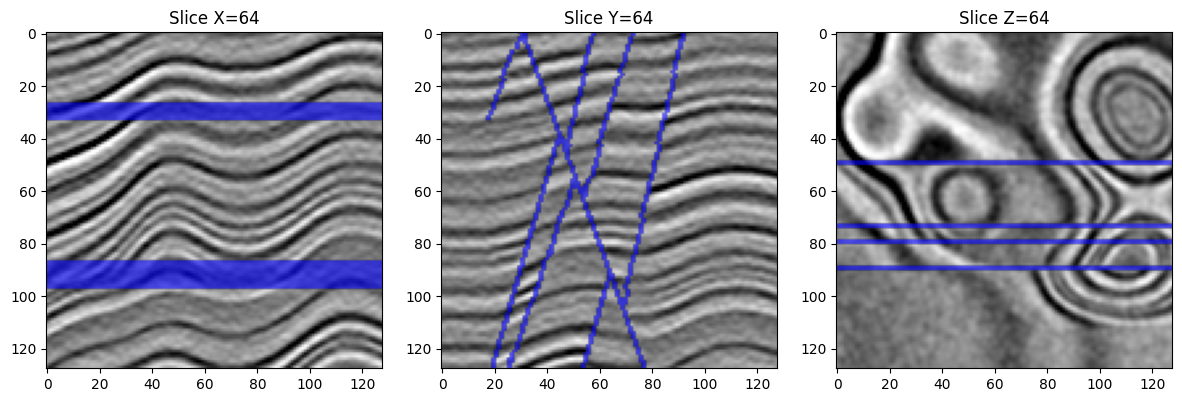

grva

 /media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset3/images/img_0105.npy


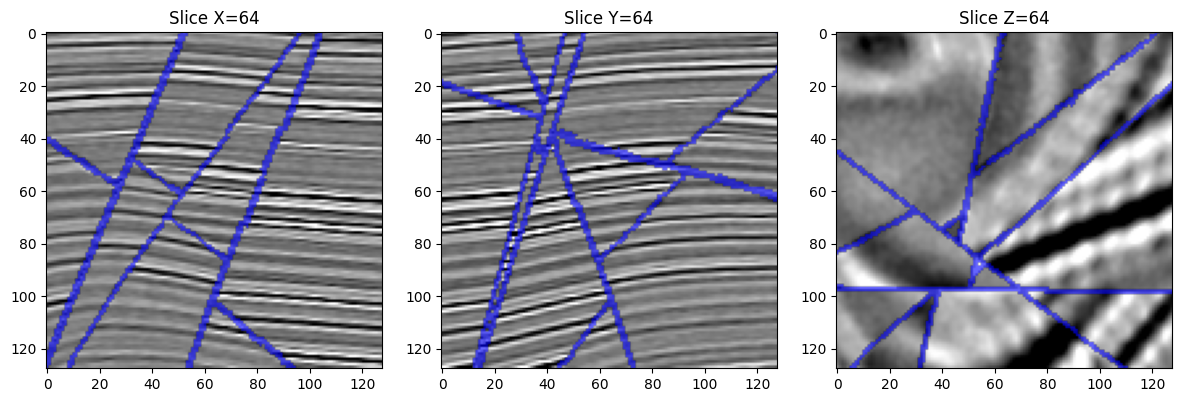

grva

 /media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset3/images/img_0106.npy


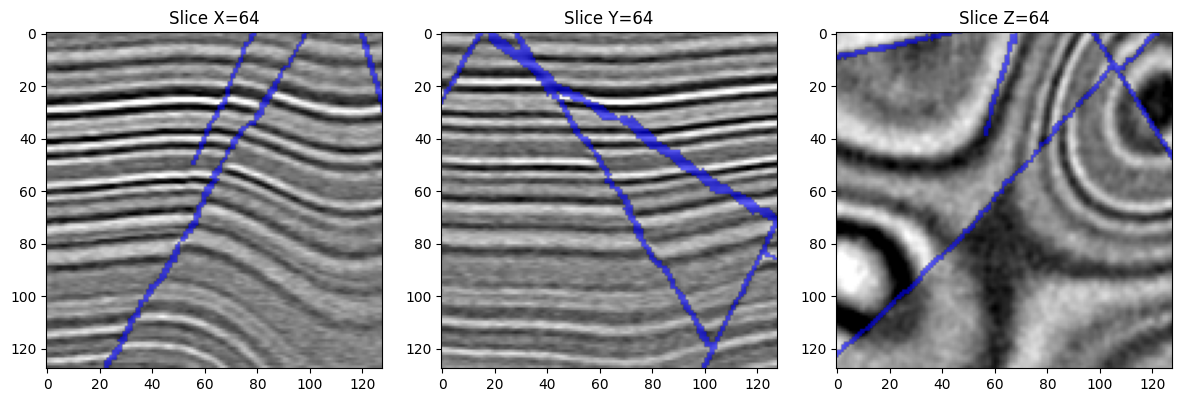

grva

 /media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset3/images/img_0107.npy


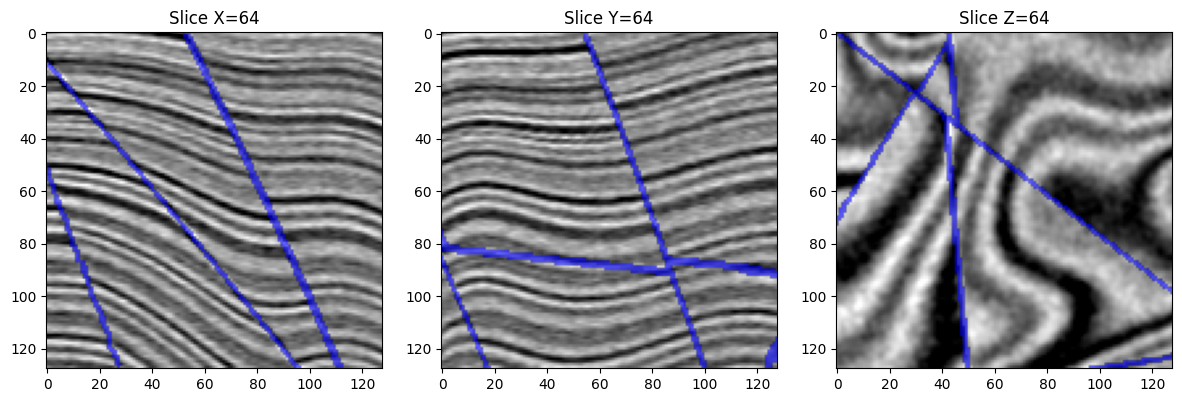

grva

 /media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset3/images/img_0108.npy


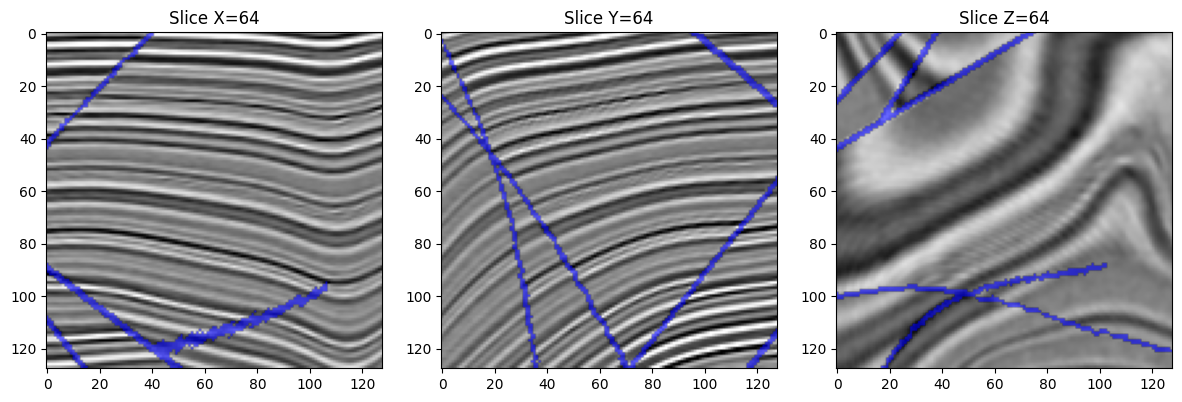

wu

 /media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/1.npy


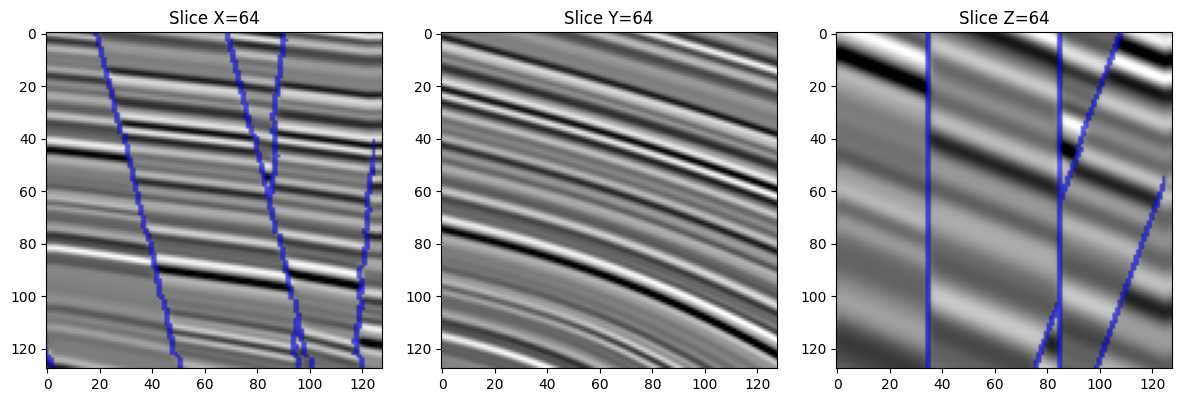

wu

 /media/grva-mintcave/BACKUP/marlim_faults/KlaussModel/Falhas/Dataset/dataset1/images/0.npy


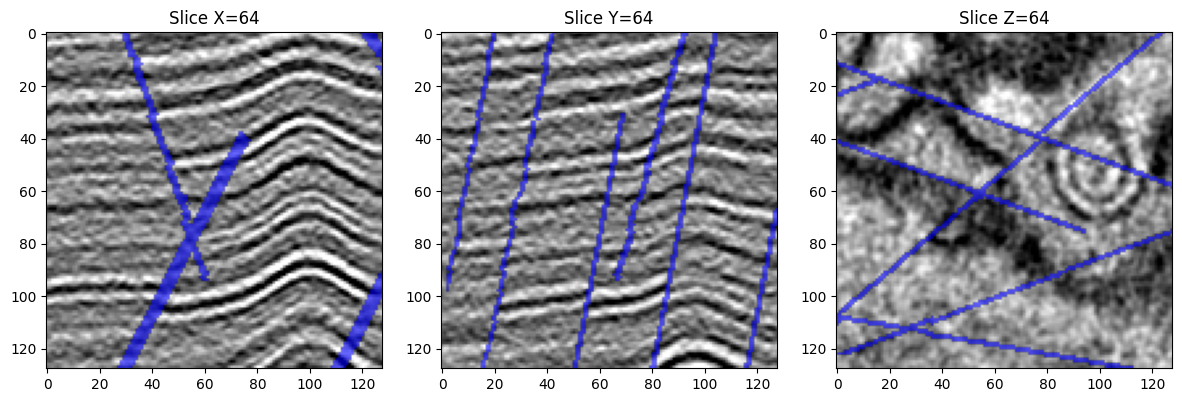

In [9]:
def showTile(img=None, mask=None, save=None):
    if img is None and mask is None:
        return print("Erro: Forneça pelo menos 'img' ou 'mask'.")

    ref_vol = img if img is not None else mask
    mid_x = ref_vol.shape[0] // 2
    mid_y = ref_vol.shape[1] // 2
    mid_z = ref_vol.shape[2] // 2

    def get_slices(vol):
        if vol is None:
            return None
        
        s_x = np.array(vol[mid_x, :, :]) # Plano YZ
        s_y = np.array(vol[:, mid_y, :]) # Plano XZ
        s_z = np.array(vol[:, :, mid_z]) # Plano XY
        return [s_x, np.rot90(s_z, -1), s_y]

    img_slices  = get_slices(img)
    mask_slices = get_slices(mask)
    cmap_mask_only    = ListedColormap(['black', 'red', 'green', 'blue'])
    cmap_mask_overlay = ListedColormap([(0, 0, 0, 0), 'red', 'green', 'blue'])

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    titles    = [f'Slice X={mid_x}', f'Slice Y={mid_y}', f'Slice Z={mid_z}']

    for i, ax in enumerate(axes):
        if img is not None:
            ax.imshow(img_slices[i], cmap='gray')
            
        if mask is not None:
            if img is not None:
                ax.imshow(mask_slices[i], cmap=cmap_mask_overlay, vmin=0, vmax=1, alpha=0.6)
            else:
                ax.imshow(mask_slices[i], cmap=cmap_mask_only, vmin=0, vmax=1)
        
        ax.set_title(titles[i])

    plt.tight_layout()

    if save:
        plt.savefig(save, bbox_inches='tight', dpi=300)
        return plt.close(fig)

    plt.show()

for id in [0, 1, 2, 3, 4, 5, -5, -4, -3, -2, 1, 0]:
    print('wu' if id >= 0 else 'grva')
    path = df.img_path.values[id]
    print('\n', path)
    showTile(img=np.load(path), mask=np.load(df.mask_path.values[id]))

In [10]:
np.load(df.img_path.values[0]).shape

(128, 128, 128)

In [11]:
df.to_csv('../DataBase.csv', index=None)